**1주차 복습과제**

📍ResNet - Deep Residual Learning for Image Recognition

교재 : <딥러닝 파이토치 교과서>

범위 : 6.1.5장 (p.312 ~ 340)

In [29]:
#필요한 라이브러리 호출

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple
import os
import random
import time

import cv2
from torch.utils.data import DataLoader, Dataset
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

- 네임드튜플:
    튜플의 성질을 갖는 자료형이지만 인덱스 뿐 아니라 키 값으로도 데이터에 접근 가능

####1. 데이터 전처리

In [30]:
#이미지 데이터 전처리

class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

In [31]:
#변수에 대한 값 정의
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [32]:
#훈련과 테스트 데이터셋 불러오기
cat_directory = r'/content/drive/MyDrive/Euron_10기research/data/dogs-vs-cats/Cat'
dog_directory = r'/content/drive/MyDrive/Euron_10기research/data/dogs-vs-cats/Dog'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

In [33]:
#데이터셋을 훈련, 검증, 테스트 용도로 분리
random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400 :-10]
test_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths),
      len(test_images_filepaths))

400 92 10


In [34]:
#이미지에 대한 레이블 구현
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):

        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase) #데이터에 전처리 적용

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog': #개면 레이블 1, 고양이면 레이블 0 부여
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

In [35]:
#이미지 데이터셋 정의
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


In [36]:
#데이터셋의 데이터를 메모리로 불러오기
train_iterator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_iterator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_iterator, 'val': valid_iterator}

batch_iterator = iter(train_iterator)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 0, 1, 1, 1, 0, 0])


---
####2. ResNet 네트워크 구성

- 기본 블록: ResNet18, ResNet 34에서 사용. 3x3 합성곱 두 개로 구성.

In [37]:
#기본 블록 정의
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)        #3×3 합성곱층
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)     #3×3 합성곱충
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if downsample:      #①
            conv = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                             stride=stride, bias=False)
            bn = nn.BatchNorm2d(out_channels)
            downsample = nn.Sequential(conv, bn)
        else:
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += I      #②
        x = self.relu(x)

        return x

↪ ① 다운샘플 적용
* 입력 데이터의 크기와 출력 데이터의 크기가 다를 경우에 사용
* 다음과 같이 합성곱층에 스트라이드를 적용
```
conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False)
```
② 아이덴티티 매핑 적용
* = Skip connection, 특정 층에 존재하는 출력 결과를 다음 합성곱층을 통과한 출력 결과에 더해 줌
* Ex) 다음과 같이 x에 `conv1, bn1, relu, conv2, bn2, relu, conv3, bn3` 값이 더해지다가 초기의 x가 다시 더해지는 것 (=아이덴티티 매핑, shortcut/skip connection)
```
def forward(self, x):
        i = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += I      #②
        x = self.relu(x)

        return x
```



- 병목 블록: ResNet50, ResNet101, ResNet152에서 사용. 1x1, 3x3, 1x1 합성곱층으로 구성.

In [38]:
#병목 블록 정의
class Bottleneck(nn.Module):
    expansion = 4       #ResNet에서 병목 블록을 정의하기 위한 하이퍼파라미터

    def __init__(self, in_channels, out_channels, stride=1, downsample=False):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                               stride=1, bias=False)       #1×1 합성곱층
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride,padding=1,bias=False)     #3×3 합성곱충
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, self.expansion*out_channels,   #1×1 합성곱충, 다음 계층의 입력 채널 수와 일치하도록 self.expansion*out_channels를 함
                               kernel_size=1, stride=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion*out_channels)
        self.relu = nn.ReLU(inplace=True)

        if downsample:
            conv = nn.Conv2d(in_channels, self.expansion*out_channels, kernel_size=1,
                             stride=stride, bias=False)
            bn = nn.BatchNorm2d(self.expansion*out_channels)
            downsample = nn.Sequential(conv, bn)
        else:
            downsample = None
        self.downsample = downsample

    def forward(self, x):
        i = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)

        if self.downsample is not None:
            i = self.downsample(i)

        x += i
        x = self.relu(x)
        return x


- 기본 블록을 병목 블록으로 변경하면 계층을 더 깊게 쌓으면서 계산에 대한 비용을 줄일 수 있음
- 계층이 많아진다는 것 = 활성화 함수가 기존보다 더 많이 포함된다는 것 -> 더 많은 비선형성을 처리할 수 있음
-> 다양한 입력 데이터에 대한 처리 가능
- 아이덴티티 매핑과 병목 블록으로 ResNet 네트워크에 더욱 깊은 계층 쌓을 수 있게 됨

- RexNet 모델 네트워크 정의

In [39]:
#ResNet 모델 네트워크
class ResNet(nn.Module):
    def __init__(self, config, output_dim, zero_init_residual=False):
        super().__init__()

        block, n_blocks, channels = config      #ResNet을 호출할 때 넘겨준 config 값들을 block, n_blocks, channels에 저장
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4      #블록 크기=채널 크기=4

        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2,
                               padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.get_resnet_layer(block, n_blocks[0], channels[0])
        self.layer2 = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
        self.layer3= self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
        self.layer4 = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)

        self.avgpool=nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(self.in_channels, output_dim)

        if zero_init_residual:      #①
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def get_resnet_layer(self, block, n_blocks, channels, stride=1):      #블록을 추가하기 위한 함수
        layers = []
        if self.in_channels != block.expansion * channels:      #in_channels와 block.expansion*channels가 다르면 downsample 적용
            downsample = True
        else:
            downsample = False

        layers.append(block(self.in_channels, channels, stride, downsample))    #계충(layer)을 추가할 때 in_channels, channels, stride뿐만 아니라 다운샘플 적용 유무도 함께 전달
        for i in range(1, n_blocks):        #n_blocks만큼 계층 추가
            layers.append(block(block.expansion*channels, channels))

        self.in_channels = block.expansion * channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)       #224x224
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)     #112x 112
        x = self.layer1(x)      #56x56
        x = self.layer2(x)      #28×28
        x = self.layer3(x)      #14x14
        x = self.layer4(x)      #7×7
        x = self.avgpool(x)     #1×1
        h =x.view(x.shape[0], -1)
        x = self.fc(h)
        return x, h

↪ ① 각 레지듀얼 분기(residual branch)에 있는 마지막 BN(Batch Normalization)을 0으로 초기화, 다음 레지듀얼 분기를 0에서 시작할 수 있도록 함
* 모델을 생성하고 학습시키는 것과는 상관 X
- BN을 0으로 초기화할 경우 모델 성능이 0.2~0.3% 정도 향상된다고 하여 ResNet에서 많이 사용되고 있음
* 레지듀얼 분기: 프로그램에서의 조건에 따라 A, B, C 등으로 분기하는 것

- ResNet의 Config 정의. 블록 종류, 블록 크기, 채널 크기를 지정.

In [40]:
#ResNetConfig 정의
ResNetConfig = namedtuple('ResNetConfig', ['block', 'n_blocks', 'channels'])

In [41]:
#기본 블록을 사용하여 ResNetConfig 정의
resnet18_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[2,2,2,2],
                               channels=[64,128,256,512])

resnet34_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[3,4,6,3],
                               channels=[64,128,256,512])

In [42]:
#병목 블록을 사용하여 ResNetConfig 정의
resnet50_config = ResNetConfig(block=Bottleneck,
                               n_blocks=[3,4,6,3],
                               channels=[64,128,256,512])

resnet101_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3,4,23,3],
                                channels=[64,128,256,512])

resnet152_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3,8,36,3],
                                channels=[64,128,256,512])

- 사전 훈련된 ResNet 모델 사용

In [43]:
#사전 훈련된 ResNet 모델 사용
pretrained_model = models.resnet50(pretrained=True)     #사전 훈련된 ResNet 모델 사용을 위해서는 pretrained=True로 설정

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [44]:
#사전 훈련된 ResNet 네트워크 확인
print(pretrained_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

- ResNet50 모델 사용하기

In [45]:
#ResNet50 Config를 사용한 ResNet 모델 사용
OUTPUT_DIM = 2      #두 개의 클래스 사용(개와 고양이)
model = ResNet(resnet50_config, OUTPUT_DIM)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [46]:
#옵티마이저와 손실 함수 정의
optimizer = optim. Adam(model.parameters(), lr=1e-7)        #lr=1e-7은 1*10의 -7승을 의미
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [47]:
#모델 학습 정확도 측정 함수 정의
def calculate_topk_accuracy(y_pred, y, k=2):
    with torch.no_grad():
        batch_size = y.shape[0]
        _, top_pred= y_pred.topk(k,1)       #①
        top_pred = top_pred.t()     #②
        correct = top_pred.eq(y.view(1,-1).expand_as(top_pred))     #③
        correct_1=correct[:1].reshape(-1).float().sum(0, keepdim=True)
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True) ##이미지의 정확한 레이블 부여를 위해 사용. 즉, 첫 번째 레이블이 아닌 정확한 레이블 부여를 위해 사용
        acc_1 = correct_1 / batch_size
        acc_k = correct_k / batch_size
    return acc_1, acc_k

↪ ① `tensor.topk`는 `torch.argmax`와 같은 효과
* 주어진 텐서에서 가장 큰 값의 인덱스를 얻기 위해 사용
* 즉, 네트워크의 출력에서 가장 확률이 높은 값의 인덱스를 반환

② t()는 차원 0과 1을 전치(transpose)

③ 텐서를 비교하는 함수
* 텐서가 서로 같은지를 비교한다면 `torch.eq`, 다른지를 비교한다면 `torch.ne`, 크거나 같은지를 비교한다면 `torch.ge`를 사용
* `torch.eq`는 다음과 같은 형식을 이용하여 사용
```
torch.eq(비교 대상 텐서, 비교할 텐서)
```
* `torch.eq`의 결과는 각 텐서의 요소들을 비교해서 같으면 True, 다르면 False를 반환


In [48]:
#모델 학습 함수 정의
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.train()
    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred =model(x)
        loss = criterion(y_pred[0], y)

        acc_1, acc_5= calculate_topk_accuracy(y_pred[0], y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc_1 += acc_1.item()     #모델이 첫 번째로 예측한 레이블이 붙여짐
        epoch_acc_5 += acc_5.item()     #이미지에 정확한 레이블이 붙여질 것이기 때문에 정확도가 100%일 것

    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

In [49]:
#모델 평가 함수 정의
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc_1 = 0
    epoch_acc_5 = 0

    model.eval()
    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)
            y_pred=model(x)
            loss = criterion(y_pred[0], y)

            acc_1, acc_5= calculate_topk_accuracy(y_pred[0], y)
            epoch_loss += loss.item()
            epoch_acc_1 += acc_1.item()
            epoch_acc_5 += acc_5.item()

        epoch_loss /= len(iterator)
        epoch_acc_1 /= len(iterator)
        epoch_acc_5 /= len(iterator)
        return epoch_loss, epoch_acc_1, epoch_acc_5

In [50]:
#모델 학습 시간 측정 함수 정의
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time/60)
    elapsed_secs= int(elapsed_time-(elapsed_mins*60))
    return elapsed_mins, elapsed_secs

In [51]:
#모델 학습
best_valid_loss = float('inf')
EPOCHS = 10

for epoch in range(EPOCHS):
    start_time = time.monotonic()

    train_loss, train_acc_1, train_acc_5 = train(model, train_iterator, optimizer,
                                                 criterion, device)
    valid_loss, valid_acc_1, valid_acc_5 = evaluate(model, valid_iterator, criterion,
                                                    device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(),'/content/drive/MyDrive/Euron_10기research/data/ResNet-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss :.3f} | Train Acc @1: {train_acc_1*100:6.2f}% | ' \
          f'Train Acc @5: {train_acc_5*100:6.2f}%')
    print(f'\tValid Loss: {valid_loss :.3f} | Valid Acc @1: {valid_acc_1*100:6.2f}% | ' \
          f'Valid Acc @5: {valid_acc_5*100:6.2f}%')

Epoch: 01 | Epoch Time: 0m 7s
	Train Loss: 0.690 | Train Acc @1:  52.40% | Train Acc @5: 100.00%
	Valid Loss: 0.750 | Valid Acc @1:  48.81% | Valid Acc @5: 100.00%
Epoch: 02 | Epoch Time: 0m 7s
	Train Loss: 0.694 | Train Acc @1:  53.61% | Train Acc @5: 100.00%
	Valid Loss: 0.757 | Valid Acc @1:  48.81% | Valid Acc @5: 100.00%
Epoch: 03 | Epoch Time: 0m 9s
	Train Loss: 0.689 | Train Acc @1:  52.16% | Train Acc @5: 100.00%
	Valid Loss: 0.752 | Valid Acc @1:  48.81% | Valid Acc @5: 100.00%
Epoch: 04 | Epoch Time: 0m 7s
	Train Loss: 0.690 | Train Acc @1:  51.92% | Train Acc @5: 100.00%
	Valid Loss: 0.710 | Valid Acc @1:  51.93% | Valid Acc @5: 100.00%
Epoch: 05 | Epoch Time: 0m 7s
	Train Loss: 0.686 | Train Acc @1:  53.61% | Train Acc @5: 100.00%
	Valid Loss: 0.679 | Valid Acc @1:  55.21% | Valid Acc @5: 100.00%
Epoch: 06 | Epoch Time: 0m 10s
	Train Loss: 0.680 | Train Acc @1:  53.61% | Train Acc @5: 100.00%
	Valid Loss: 0.668 | Valid Acc @1:  62.95% | Valid Acc @5: 100.00%
Epoch: 07 | Epo

In [52]:
#테스트 데이터셋을 이용한 모델 예측
import pandas as pd
id_list = []
pred_list = []
_id = 0
with torch.no_grad():
    for test_path in test_images_filepaths:
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs[0], dim=1) [:, 1].tolist()
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('/content/drive/MyDrive/Euron_10기research/data/ResNet.csv', index=False)
res.head(10)

,id,label
0,109,0.483367
1,145,0.445619
2,15,0.447039
3,162,0.465030
4,167,0.421310
5,200,0.479476
6,210,0.510887
7,211,0.405717
8,213,0.374964
9,224,0.436423


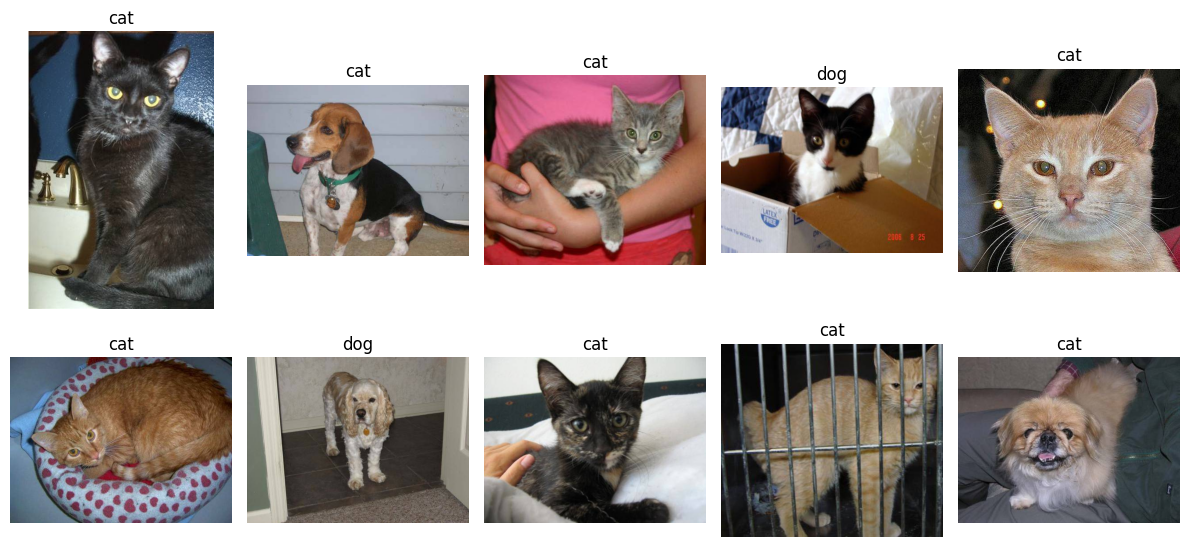

In [53]:
#모델 예측에 대한 결과 출력
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a = random.choice(res['id'].values)
        label = res.loc[res['id' ] == a, 'label'].values[0]

        if label > 0.5:
            label = 1
        else:
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()
display_image_grid(test_images_filepaths)